### Import bibliotek

In [12]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 1
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)


ADOPTION_SPEED_LABELS = {
    0: '0',
    1: '1–7',
    2: '8–30',
    3: '31–90',
    4: '>100',
}
ADOPTION_SPEED_ORDER = [ADOPTION_SPEED_LABELS[i] for i in range(5)]

### Wczytanie danych

In [13]:
INPUT_PATH = '../data/processed/train_clean.csv'
OUTPUT_PATH = '../data/processed/train_clean_anomaly.csv'

FEATURE_COLS = ['Age', 'Fee', 'Quantity', 'PhotoAmt', 'DescLength']

df = pd.read_csv(INPUT_PATH)
shape_before = df.shape

print('Podglad danych:')
display(df.head())

print(f'\nShape: {df.shape}')

Podglad danych:


,Type,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,FurLength,...,Health,Quantity,Fee,RescuerID,VideoAmt,PetID,PhotoAmt,AdoptionSpeed,HasName,DescLength
0,2,3,299,0,1,1,7,0,1,1,...,1,1,100,8480853f516546f6cf33aa88cd76c379,0,86e1089a3,1.0,2,1,359
1,2,1,265,0,1,1,2,0,2,2,...,1,1,0,3082c7125d8fb66f7dd4bff4192c8b14,0,6296e909a,2.0,0,1,118
2,1,1,307,0,1,2,7,0,2,2,...,1,1,0,fa90fa5b1ee11c86938398b60abc32cb,0,3422e4906,7.0,3,1,393
3,1,4,307,0,2,1,2,0,2,1,...,1,1,150,9238e4f44c71a75282e62f7136c6b240,0,5842f1ff5,8.0,2,1,146
4,1,1,307,0,1,1,0,0,2,1,...,1,1,0,95481e953f8aed9ec3d16fc4509537e8,0,850a43f90,3.0,2,1,390



Shape: (14993, 23)


### Isolation Forest

In [14]:
X = df[FEATURE_COLS].copy()

# Skalowanie cech
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

iso_forest = IsolationForest(
    contamination=0.05,
    random_state=RANDOM_STATE,
)
iso_forest.fit(X_scaled)

# -1 = anomalia, 1 = normalny rekord
predictions = iso_forest.predict(X_scaled)
df['is_anomaly'] = (predictions == -1).astype(int)

n_anomalies = df['is_anomaly'].sum()
pct_anomalies = n_anomalies / len(df) * 100

print(f'Wykryte anomalie: {n_anomalies}')
print(f'Udział anomalii: {pct_anomalies:.2f}%')

Wykryte anomalie: 750
Udział anomalii: 5.00%


### Wizualizacje anomalii

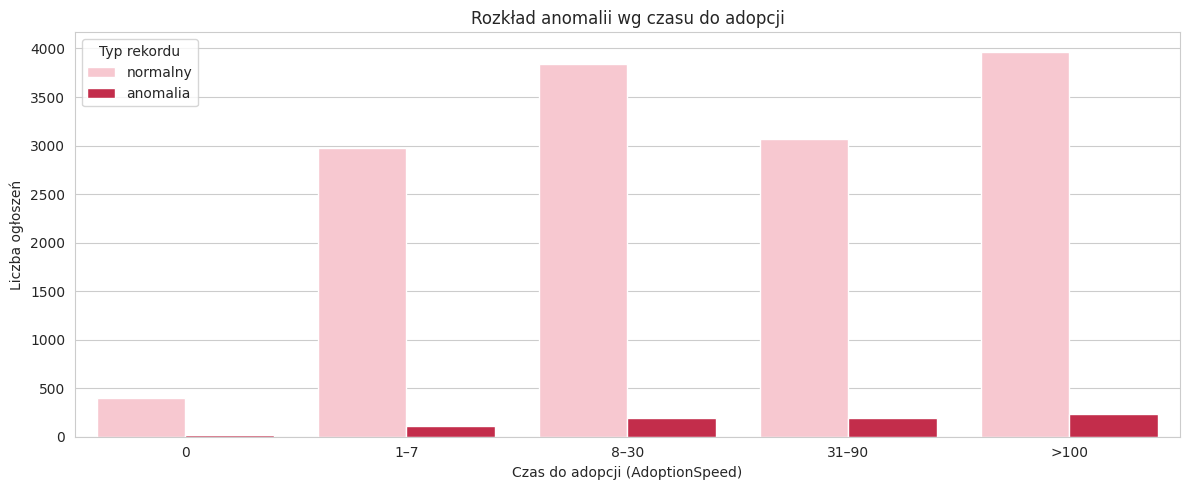

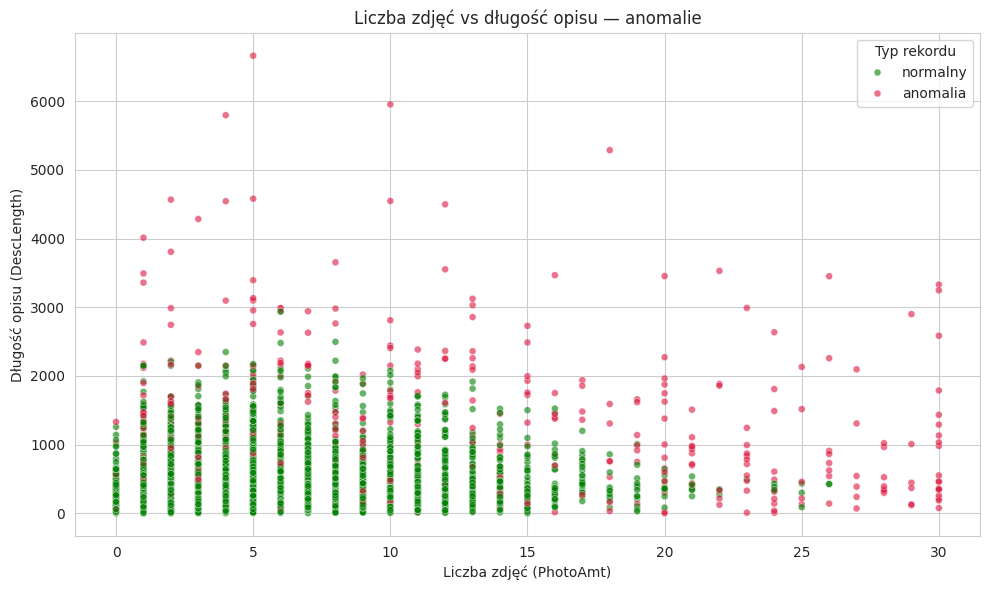

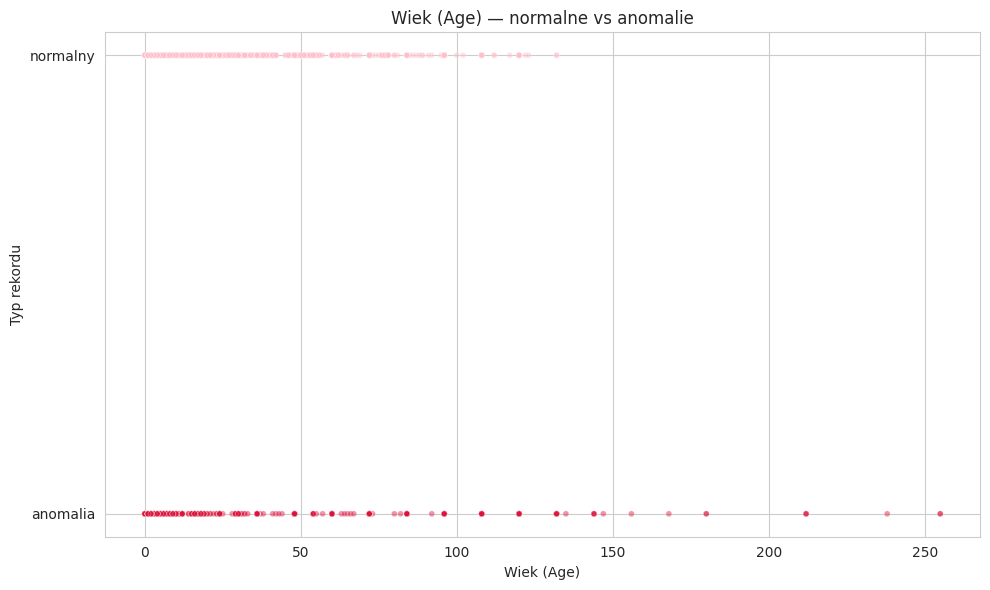

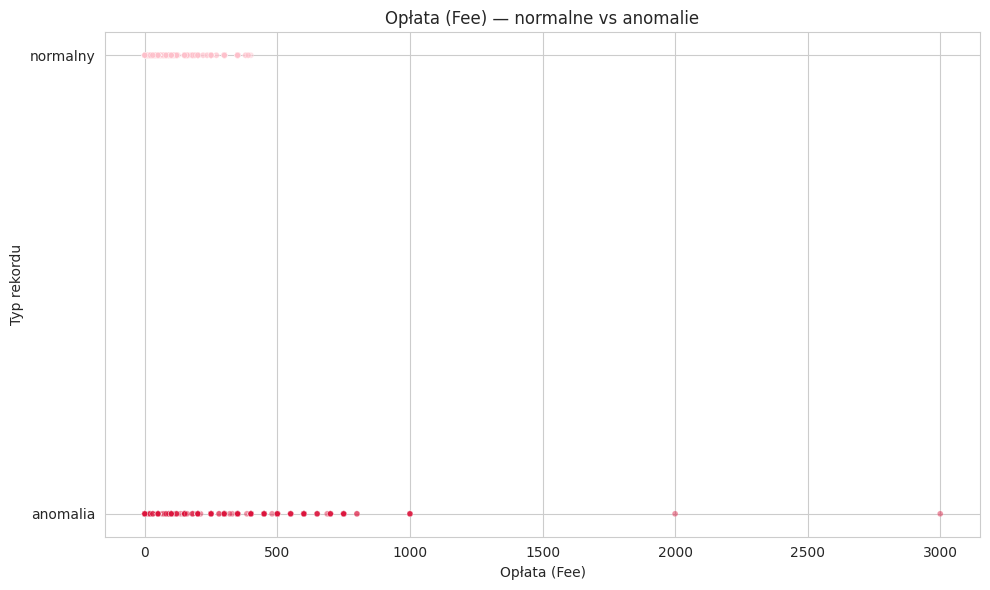

In [ ]:
df_plot = df.assign(
    Typ_rekordu=df['is_anomaly'].map({0: 'normalny', 1: 'anomalia'}),
    Czas_adopcji=df['AdoptionSpeed'].map(ADOPTION_SPEED_LABELS),
)
plt.figure(figsize=(12, 5))
sns.countplot(
    data=df_plot,
    x='Czas_adopcji',
    hue='Typ_rekordu',
    order=ADOPTION_SPEED_ORDER,
    palette={"normalny": "pink", "anomalia": "crimson"},
)
plt.title('Rozkład anomalii wg czasu do adopcji')
plt.xlabel('Czas do adopcji (AdoptionSpeed)')
plt.ylabel('Liczba ogłoszeń')
plt.legend(title='Typ rekordu')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_plot,
    x='PhotoAmt',
    y='DescLength',
    hue='Typ_rekordu',
    palette={"normalny": "green", "anomalia": "crimson"},
    alpha=0.6,
    s=25,
)
plt.title('Liczba zdjęć vs długość opisu — anomalie')
plt.xlabel('Liczba zdjęć (PhotoAmt)')
plt.ylabel('Długość opisu (DescLength)')
plt.legend(title='Typ rekordu')
plt.tight_layout()
plt.show()

### Zapis przetworzonych danych